# Floating-Point Rounding and Pearson Correlation

This notebook investigates an unexpected result: two exactly constant arrays can produce a Pearson correlation of `+1` or `-1` instead of `NaN`.

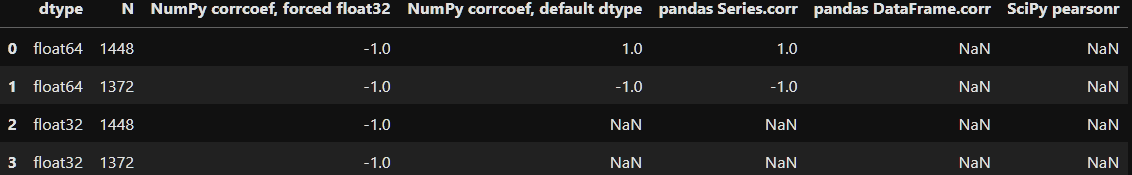

It builds on [Part I](01_Floating_point_arithmetic_rounding_error_Part-I.ipynb) and [Part II](02_Floating_point_arithmetic_rounding_error_Part-II.ipynb) of the standard-deviation investigation. Those notebooks show how floating-point reduction can report a small non-zero standard deviation for constant data. Here, the same effect is examined in NumPy and pandas correlation calculations.

## 1. Pearson Correlation and Constant Inputs

The Pearson correlation coefficient measures the direction and strength of a linear association between two variables, where $s_x$ and $s_y$ are the sample standard deviations:

$$
r = \frac{1}{N-1}\sum_{i=1}^{N}
\frac{(x_i-\bar{x})(y_i-\bar{y})}{s_x s_y}
$$

Equivalently, the formula can be written as:

$$
r = \frac{\sum_{i=1}^{N}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{N}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{N}(y_i-\bar{y})^2}}.
$$

Common interpretations are:

- $r=+1$: perfect positive linear association;
- $r=0$: no linear association;
- $r=-1$: perfect negative linear association.

If either input is constant, its centered sum of squares is zero. The denominator is therefore zero, so the correlation is mathematically undefined and should be represented by `NaN`.

Correlation describes association, not causation or prediction accuracy. When comparing measured and predicted values, metrics such as MAE and RMSE answer different—and often more relevant—questions.

## 2. Minimal Reproducible Example

The examples below use the same constant values and selected lengths as the preceding notebooks. The behavior is version-specific, so the library versions are printed explicitly.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy import __version__ as scipy_version
from IPython.display import display

print('Numpy version:',np.__version__)
print('Pandas version:',pd.__version__)
print("SciPy version:", scipy_version)

Numpy version: 2.5.2
Pandas version: 3.0.5
SciPy version: 1.18.0


In [2]:
def correlation_report(dtype, n):
    x = np.full(n, dtype(1.810), dtype=dtype)
    y = np.full(n, dtype(0.576), dtype=dtype)
    frame = pd.DataFrame({"X": x, "Y": y})

    # The stored values are exactly constant.
    assert np.all(x == x[0])
    assert np.all(y == y[0])

    with np.errstate(divide="ignore", invalid="ignore"):
        numpy_corr_forced_float32 = np.corrcoef(
            x, y, dtype=np.float32
        )[0, 1]
        numpy_corr = np.corrcoef(x, y)[0, 1]
        series_corr = frame["X"].corr(frame["Y"])
        dataframe_corr = frame.corr().loc["X", "Y"]

    return {
        "dtype": dtype.__name__,
        "N": n,
        "NumPy corrcoef, forced float32": numpy_corr_forced_float32,
        "NumPy corrcoef, default dtype": numpy_corr,
        "pandas Series.corr": series_corr,
        "pandas DataFrame.corr": dataframe_corr,
        "SciPy pearsonr": stats.pearsonr(x,y)[0]
    }


correlation_results = pd.DataFrame(
    correlation_report(dtype, n)
    for dtype in (np.float64, np.float32)
    for n in (1448, 1372)
)

correlation_results

C:\Users\Alexa\AppData\Local\Temp\ipykernel_10744\1668020110.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "SciPy pearsonr": stats.pearsonr(x,y)[0]


,dtype,N,"NumPy corrcoef, forced float32","NumPy corrcoef, default dtype",pandas Series.corr,pandas DataFrame.corr,SciPy pearsonr
0,float64,1448,-1.0,1.0,1.0,NaN,NaN
1,float64,1372,-1.0,-1.0,-1.0,NaN,NaN
2,float32,1448,-1.0,NaN,NaN,NaN,NaN
3,float32,1372,-1.0,NaN,NaN,NaN,NaN


For these test cases:

- `np.corrcoef()` with its default dtype and pandas `Series.corr()` return `+1` or `-1` for the float64 input arrays;
- both return `NaN` for the float32 input arrays;
- explicitly passing `dtype=np.float32` to `np.corrcoef()` produces a finite correlation for all four cases;
- pandas `DataFrame.corr()` returns `NaN` in all four cases.
- SciPy `pearsonr` returns `NaN` in all four cases and warns the user of the input array being constant.

The inputs are constant in every case. The differing results arise from different numerical paths, not from variation in the stored data.

In [3]:
def precision_report(dtype, n):
    x = np.full(n, dtype(1.810), dtype=dtype)
    y = np.full(n, dtype(0.576), dtype=dtype)

    return {
        "dtype": dtype.__name__,
        "N": n,
        "X mean error": x.mean() - x[0],
        "Y mean error": y.mean() - y[0],
        "NumPy std(X)": x.std(ddof=1),
        "pandas std(X)": pd.Series(x).std(ddof=1),
        "NumPy std(Y)": y.std(ddof=1),
        "pandas std(Y)": pd.Series(y).std(ddof=1),
    }


precision_results = pd.DataFrame(
    precision_report(dtype, n)
    for dtype in (np.float64, np.float32)
    for n in (1448, 1372)
)

precision_results

,dtype,N,X mean error,Y mean error,NumPy std(X),pandas std(X),NumPy std(Y),pandas std(Y)
0,float64,1448,-2.220446e-16,-1.110223e-16,2.221213e-16,2.221213e-16,1.110607e-16,1.110607e-16
1,float64,1372,4.440892e-16,-2.220446e-16,4.442511e-16,4.442511e-16,2.221256e-16,2.221256e-16
2,float32,1448,-3.576279e-07,1.192093e-07,3.577514e-07,0.000000e+00,1.192505e-07,0.000000e+00
3,float32,1372,-2.384186e-07,1.192093e-07,2.385055e-07,0.000000e+00,1.192528e-07,0.000000e+00


## 3. Why an Exactly Constant Pair Can Produce ±1

For a constant array, the exact mean equals every element. In floating-point arithmetic, however, summation followed by division can produce a mean that differs from the stored value by one or more representable steps.

If the computed mean is slightly wrong, every centered value in a constant array has the same small residual. Two residual vectors with the same sign appear perfectly positively correlated; residual vectors with opposite signs appear perfectly negatively correlated.

The following simplified calculation demonstrates the numerical mechanism for these examples.

In [4]:
def residual_report(n):
    x = np.full(n, 1.810, dtype=np.float64)
    y = np.full(n, 0.576, dtype=np.float64)
    x_residual = x - x.mean()
    y_residual = y - y.mean()

    numerator = np.sum(x_residual * y_residual)
    denominator = np.sqrt(
        np.sum(x_residual**2) * np.sum(y_residual**2)
    )

    return {
        "N": n,
        "X residual": x_residual[0],
        "Y residual": y_residual[0],
        "numerator": numerator,
        "denominator": denominator,
        "manual correlation": numerator / denominator,
    }


pd.DataFrame(residual_report(n) for n in (1448, 1372))

,N,X residual,Y residual,numerator,denominator,manual correlation
0,1448,2.220446e-16,1.110223e-16,3.569596e-29,3.569596e-29,1.0
1,1372,-4.440892e-16,2.220446e-16,-1.352896e-28,1.352896e-28,-1.0


At $N=1{,}448$, both residuals have the same sign, producing $+1$. At $N=1{,}372$, their signs differ, producing $-1$.

These values do not reveal a real relationship. They are artifacts of applying the Pearson formula to numerical residuals created by rounding. The true centered vectors contain only zeros, for which the correlation is undefined.

### 3.1 Why the float32 Results Differ

`np.std()` normally retains a float32 accumulator for a float32 input, so it can report a small non-zero standard deviation here. By contrast, `np.corrcoef()` uses float64 precision for its result and calculation path by default. Once the stored float32 values are represented in float64, their mean is exact in these examples and the zero denominator produces `NaN`.

`np.corrcoef()` delegates covariance calculation to `np.cov()`. When `dtype=None`, `np.cov()` selects `np.result_type(x, y, np.float64)`, so the calculation uses at least float64 precision. Passing `dtype=np.float32` overrides that choice, converts the working input matrix to float32, and can produce artificial non-zero covariance and a finite correlation for these constant arrays.

This is an important comparison rule: a separately calculated standard deviation does not necessarily reproduce the internal precision or algorithm used by a correlation function.

In [5]:
x32 = np.full(1448, np.float32(1.810), dtype=np.float32)
x32_as_float64 = x32.astype(np.float64)

pd.Series({
    "float32 mean error": x32.mean() - x32[0],
    "mean error after float64 conversion": (
        x32_as_float64.mean() - x32_as_float64[0]
    ),
    "NumPy float32 standard deviation": x32.std(ddof=1),
})

float32 mean error                    -3.576279e-07
mean error after float64 conversion    0.000000e+00
NumPy float32 standard deviation       3.577514e-07
dtype: float64

## 4. Why the pandas APIs Disagree

In pandas 3.0.5, the relevant internal paths are:

`Series.corr() → pandas.core.nanops.nancorr() → pandas.core.nanops.get_corr_func() → np.corrcoef()`

`DataFrame.corr() → pandas._libs.algos.nancorr()`

`Series.corr()` first converts both Series to NumPy arrays using `dtype=float`, which is float64 in this environment, and then delegates Pearson correlation to `np.corrcoef()` through `pandas.core.nanops.nancorr()`. It therefore follows `np.corrcoef()` for this example.

`DataFrame.corr()` converts its numeric matrix to a NumPy float64 array, but computes Pearson correlation using pandas' separate Cython routine, `pandas._libs.algos.nancorr()`. It does not call `np.corrcoef()` for this path, and it returns `NaN` for these constant columns.

Both `pandas.core.nanops` and `pandas._libs` are private implementation modules. They are useful for understanding the observed result, but user code should rely on the public `Series.corr()` and `DataFrame.corr()` APIs because internal paths can change between releases.

## 5. SciPy behavior

In the SciPy version printed above, the public `scipy.stats.pearsonr()` function performs an explicit element-wise check for constant inputs. If either input is constant, it returns `NaN` and emits `ConstantInputWarning` with the message: `An input array is constant; the correlation coefficient is not defined.` The implementation currently lives in the private module `scipy.stats._stats_py`, which can change between releases.

## 6. Effect on Lagged Correlation

For a positive lag $k$, this notebook pairs $X_t$ with $Y_{t+k}$. Starting with $N=1{,}448$ and applying $k=76$ leaves $1{,}372$ paired observations. Because the reduction length changes, the rounding errors can change sign, turning the spurious correlation from $+1$ into $-1$.

The `guard_constant=False` calls reproduce the original unprotected use of `np.corrcoef()`. The default guarded calls check exact constancy for each Series or each DataFrame column and return `NaN` for the affected correlations.

The example class assumes that the selected data contain no missing values; NaN handling is outside the scope of this notebook.

In [6]:
class CrossCorrLag():
    def __init__(self, matrix1, matrix2):
        if not (
            isinstance(matrix1, pd.Series) and isinstance(matrix2, pd.Series)
            or isinstance(matrix1, pd.DataFrame) and isinstance(matrix2, pd.DataFrame)
        ):
            raise TypeError(
                "matrix1 and matrix2 must both be Series or both be DataFrames"
            )
        
        self.matrix1 = matrix1
        self.matrix2 = matrix2
        self.lag_value = None
        self.matrix_lag = None
        self.corr_matrix = None

    def lag(self,lag_value):
        if isinstance(lag_value, bool) or not isinstance(lag_value, int) or lag_value < 0:
            raise ValueError("lag_value must be a non-negative integer")
            
        if lag_value >= len(self.matrix1):
            raise ValueError("lag_value must be smaller than the number of samples")
            
        self.lag_value = lag_value
        self.matrix_lag = self.matrix2.iloc[self.lag_value:].copy()
        
        if isinstance(self.matrix_lag, pd.DataFrame):
            self.matrix_lag = self.matrix_lag.add_suffix(f"_lag+{self.lag_value:02d}")
            
        elif isinstance(self.matrix_lag, pd.Series):
            name = self.matrix_lag.name
            self.matrix_lag = self.matrix_lag.rename(f"{name}_lag+{self.lag_value:02d}")
        

    def corr(self, guard_constant = True):
        if self.lag_value is None:
            raise RuntimeError("Run .lag() first. Use .lag(0) for non-shifted correlation.")
            
        if len(self.matrix1) != len(self.matrix2):
            raise ValueError(
                'Shape mismatch. Matrix1 and Matrix2 must contain the same number of rows!'
            )
            
        if self.lag_value == 0:
            X = self.matrix1.to_numpy(dtype=np.float64)
        else:
            X = self.matrix1.iloc[:-self.lag_value].to_numpy(dtype=np.float64)
            
        Y = self.matrix_lag.to_numpy(dtype=np.float64)

        if isinstance(self.matrix1, pd.Series):

           if guard_constant and (np.all(X == X[0]) or np.all(Y == Y[0])):
               corr = np.nan
           else:
               with np.errstate(divide="ignore", invalid="ignore"):
                   corr = np.corrcoef(X, Y)[0, 1]

           self.corr_matrix = pd.DataFrame(
               [[corr]],
               index=[self.matrix1.name],
               columns=[self.matrix_lag.name]
               )
        else:
            with np.errstate(divide="ignore", invalid="ignore"):
                corr_values = np.corrcoef(
                    X.T, Y.T
                )[:X.shape[1], X.shape[1]:]

            if guard_constant:
                X_constant = np.all(X == X[0, :], axis=0)
                Y_constant = np.all(Y == Y[0, :], axis=0)
                corr_values[X_constant, :] = np.nan
                corr_values[:, Y_constant] = np.nan

            self.corr_matrix = pd.DataFrame(
               corr_values,
               index=self.matrix1.columns,
               columns=self.matrix_lag.columns
               )
        return self.corr_matrix


Testing with Series:

In [7]:
n = 1448
x = pd.Series(np.full(n, 1.810), name="X")
y = pd.Series(np.full(n, 0.576), name="Y")
lagged = CrossCorrLag(x, y)

for lag in (0, 76):
    print(f"Lag {lag}, without constant guard:")
    lagged.lag(lag)
    display(lagged.corr(False))
    print(f"\nLag {lag}, with constant guard:")
    lagged.lag(lag)
    display(lagged.corr(True))
    print('-' * 40)


Lag 0, without constant guard:


,Y_lag+00
X,1.0



Lag 0, with constant guard:


,Y_lag+00
X,NaN


----------------------------------------
Lag 76, without constant guard:


,Y_lag+76
X,-1.0



Lag 76, with constant guard:


,Y_lag+76
X,NaN


----------------------------------------


Testing with DataFrame:

In [8]:
np.random.seed(42)

example = pd.DataFrame({
    "voltage_constant": np.full(1448, 1.810),
    "current_constant": np.full(1448, 0.576),
    "temperature_varying": np.linspace(20.0, 25.0, 1448),
    "noise": np.random.randn(1448)
})

lagged = CrossCorrLag(example, example)

for lag in (0, 76):
    print(f"Lag {lag}, without constant guard:")
    lagged.lag(lag)
    display(lagged.corr(False))
    print(f"\nLag {lag}, with constant guard:")
    lagged.lag(lag)
    display(lagged.corr(True))

Lag 0, without constant guard:


,voltage_constant_lag+00,current_constant_lag+00,temperature_varying_lag+00,noise_lag+00
voltage_constant,1.000000e+00,1.000000e+00,2.038420e-16,7.465785e-18
current_constant,1.000000e+00,1.000000e+00,2.038420e-16,7.465785e-18
temperature_varying,2.038420e-16,2.038420e-16,1.000000e+00,3.778173e-02
noise,7.465785e-18,7.465785e-18,3.778173e-02,1.000000e+00



Lag 0, with constant guard:


,voltage_constant_lag+00,current_constant_lag+00,temperature_varying_lag+00,noise_lag+00
voltage_constant,NaN,NaN,NaN,NaN
current_constant,NaN,NaN,NaN,NaN
temperature_varying,NaN,NaN,1.000000,0.037782
noise,NaN,NaN,0.037782,1.000000


Lag 76, without constant guard:


,voltage_constant_lag+76,current_constant_lag+76,temperature_varying_lag+76,noise_lag+76
voltage_constant,1.000000e+00,-1.000000e+00,1.362303e-16,2.000083e-17
current_constant,-1.000000e+00,1.000000e+00,-1.362303e-16,-2.000083e-17
temperature_varying,-4.389643e-16,4.389643e-16,1.000000e+00,2.717996e-02
noise,5.254456e-18,-5.254456e-18,2.522308e-02,-1.264155e-03



Lag 76, with constant guard:


,voltage_constant_lag+76,current_constant_lag+76,temperature_varying_lag+76,noise_lag+76
voltage_constant,NaN,NaN,NaN,NaN
current_constant,NaN,NaN,NaN,NaN
temperature_varying,NaN,NaN,1.000000,0.027180
noise,NaN,NaN,0.025223,-0.001264


## 7. Practical Safeguard for Wide Datasets

A dataset with thousands of columns can contain channels that remain constant during a selected time window. Before computing a correlation matrix, identify those columns explicitly. This prevents numerical noise from being interpreted as signal and also records why some columns were excluded.

For exact constants, equality is the correct test. If the application needs to treat nearly constant sensor channels as constant, define a tolerance from measurement resolution or engineering requirements rather than choosing an arbitrary floating-point threshold.

In [9]:
n_unique = example.nunique(dropna=True)

constant_columns = n_unique.eq(1)
all_nan_columns = n_unique.eq(0)
include_in_correlation = n_unique.gt(1)

column_check = pd.DataFrame({
    "n_unique": n_unique,
    "is_constant": constant_columns,
    "is_all_nan": all_nan_columns,
    "include_in_correlation": include_in_correlation,
})

column_check

,n_unique,is_constant,is_all_nan,include_in_correlation
voltage_constant,1,True,False,False
current_constant,1,True,False,False
temperature_varying,1448,False,False,True
noise,1448,False,False,True


In [10]:
varying_columns = example.columns[include_in_correlation]
safe_correlation_matrix = example[varying_columns].corr()

safe_correlation_matrix

,temperature_varying,noise
temperature_varying,1.000000,0.037782
noise,0.037782,1.000000


## 8. Conclusion

Pearson correlation is undefined when either input is constant. Nevertheless, floating-point reductions can create uniform non-zero residuals from exactly constant arrays when performed at insufficient working precision. Depending on the residual signs, `np.corrcoef()` and pandas `Series.corr()` can then return a misleading correlation of `+1` or `-1`.

The differing NumPy, pandas Series, and pandas DataFrame results do not contradict the mathematics; they reflect different dtype conversions and numerical implementations. The reliable application-level solution is to detect constant inputs before calculating Pearson correlation and return `NaN`—or exclude and document those variables—rather than relying on a numerically calculated standard deviation to identify them.